In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Dataset Information

print("Shape :", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape : (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int32
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [3]:
#Desc Statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Add Species Names

df["flower_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,flower_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


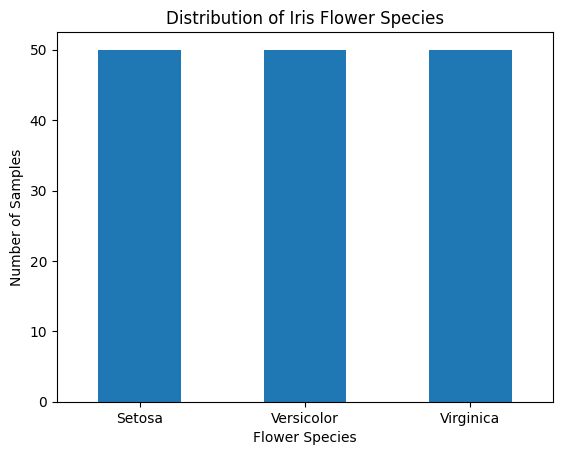

In [5]:
# Species Distribution

import matplotlib.pyplot as plt

df["flower_name"].value_counts().plot(kind="bar")

plt.title("Distribution of Iris Flower Species")
plt.xlabel("Flower Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

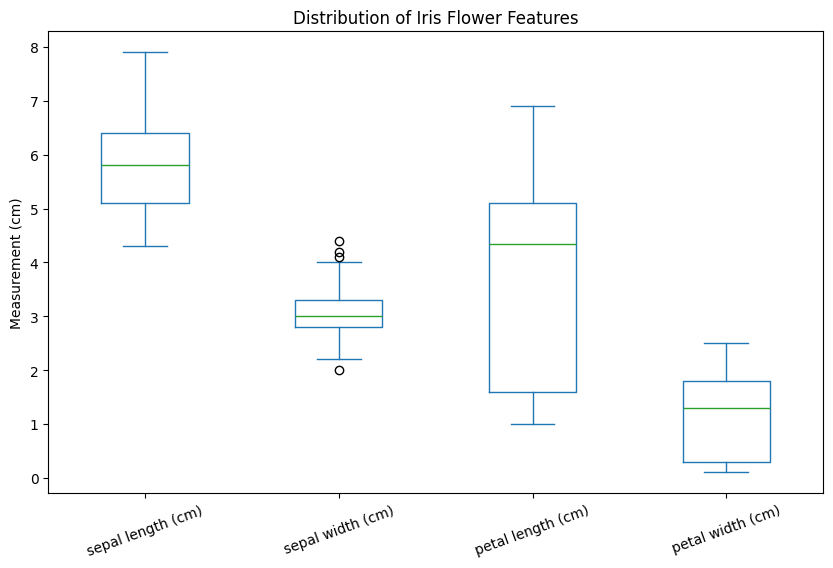

In [6]:
# Box Plot of Iris Features

features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

df[features].plot(kind="box", figsize=(10, 6))

plt.title("Distribution of Iris Flower Features")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=20)
plt.show()

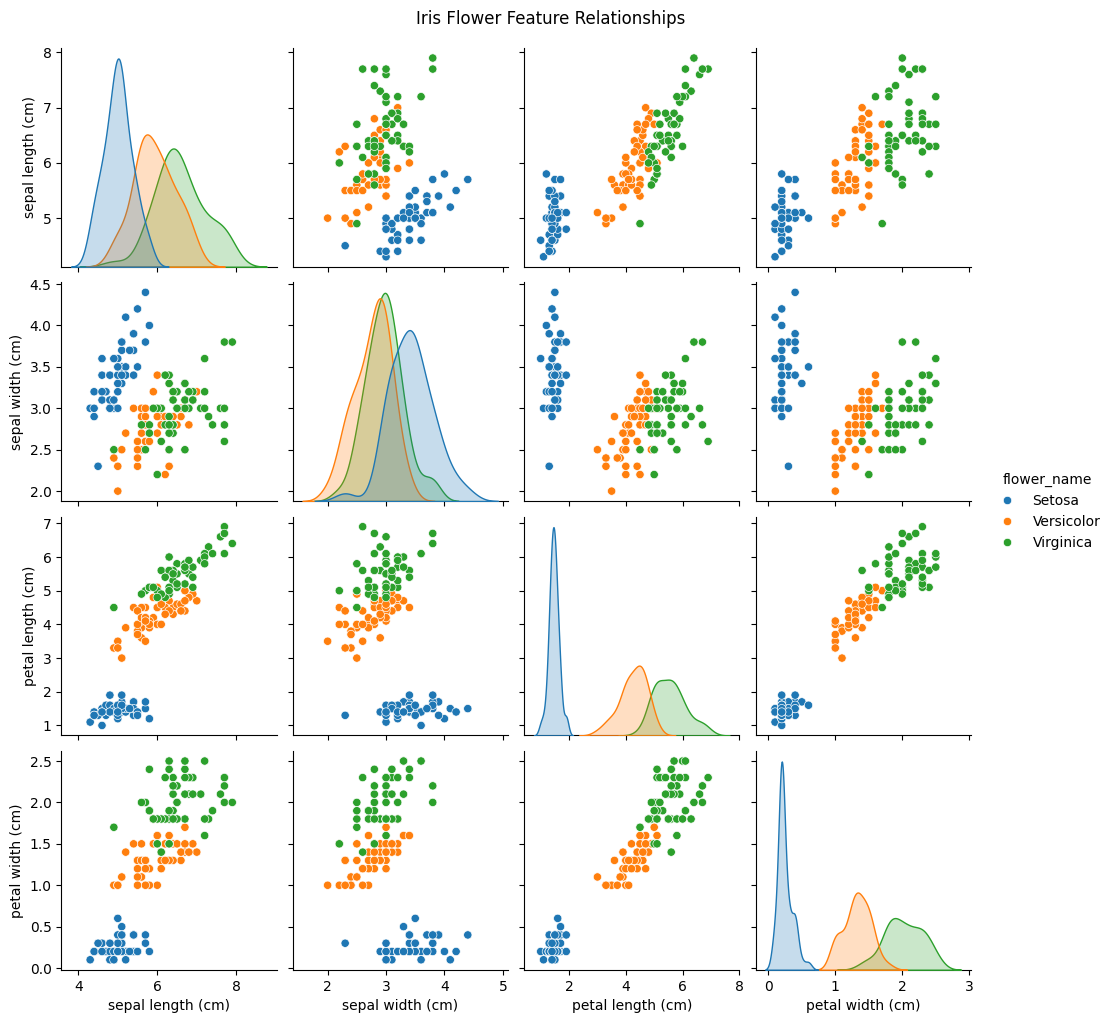

In [7]:
# Pair Plot - Feature Relationships

import seaborn as sns

sns.pairplot(
    df,
    vars=features,
    hue="flower_name"
)

plt.suptitle("Iris Flower Feature Relationships", y=1.02)
plt.show()

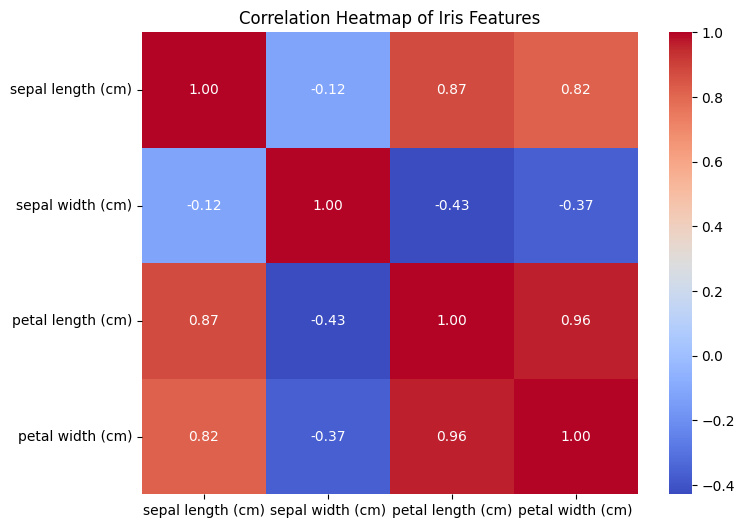

In [8]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

correlation = df[features].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Iris Features")
plt.show()

In [9]:
# Data Preparation

X = df[features]
y = df["species"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int32


In [10]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [11]:
# Model Training

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
# Model Prediction

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [13]:
# Model Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %


In [14]:
# Classification Report

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Versicolor", "Virginica"]
))

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



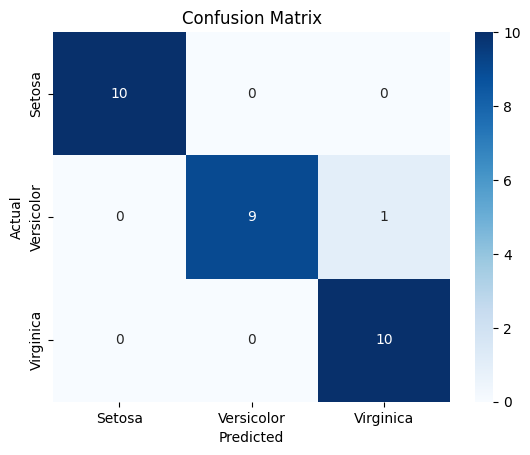

In [15]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Setosa", "Versicolor", "Virginica"],
    yticklabels=["Setosa", "Versicolor", "Virginica"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# Feature Importance

importance = model.coef_[0]

for feature, value in zip(features, importance):
    print(feature, ":", value)

sepal length (cm) : -0.5295452998680114
sepal width (cm) : 0.8272646376345799
petal length (cm) : -2.3473731760017342
petal width (cm) : -0.993393047044939


In [17]:
# Sample Prediction

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

target_names = ["Setosa", "Versicolor", "Virginica"]

print("Predicted Species:", target_names[prediction[0]])

Predicted Species: Setosa


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [18]:
# Save Model

import joblib

joblib.dump(model, "iris_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

The Iris Flower Classification model successfully classified the Iris flower species using Logistic Regression. The model achieved 96.67% accuracy on the test dataset. The analysis also showed the relationships between different flower features and their importance in classification.